# Daily Challenge: Bank Customer Churn Prediction
## Week 5 — Day 3 | DI GenAI & Machine Learning Bootcamp 2026

**Objective:** Predict whether a bank customer will churn (leave the bank) based on their profile and account data.

**Dataset:** 10,000 bank customers with 13 features  
**Target:** `Exited` — 0 = Stayed, 1 = Churned

## Step 1 — Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/leeroybenaich/DI526')
os.makedirs('week5/day3', exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded ✓")

Libraries loaded ✓


## Step 2 — Load & Explore the Dataset

In [2]:
df = pd.read_csv('week5/day3/churn_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nChurn rate: {df['Exited'].mean()*100:.1f}%")
print(f"  → Stayed: {(df['Exited']==0).sum()} customers")
print(f"  → Churned: {(df['Exited']==1).sum()} customers")

print(f"\nMissing values: {df.isnull().sum().sum()}")
print("\nData types:")
print(df.dtypes)
df.head()

Dataset shape: (10000, 14)

Churn rate: 24.2%
  → Stayed: 7583 customers
  → Churned: 2417 customers

Missing values: 0

Data types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15698454,Customer_1,850,France,Male,45,8,0.00,1,0,0,12674.97,0
1,2,15776870,Customer_2,792,Spain,Female,39,10,0.00,2,0,0,89757.03,0
2,3,15791490,Customer_3,454,Germany,Female,33,4,81067.74,1,1,1,60176.76,0
3,4,15650891,Customer_4,763,Germany,Female,30,9,0.00,1,1,0,34197.90,0
4,5,15769031,Customer_5,659,France,Male,79,1,141868.36,2,0,1,55214.89,0


In [3]:
print(df.describe().round(2))

       RowNumber   CustomerId  CreditScore       Age    Tenure    Balance  \
count   10000.00     10000.00     10000.00  10000.00  10000.00   10000.00   
mean     5000.50  15690367.85       649.79     54.20      5.11   90608.44   
std      2886.90     72339.79        97.82     21.35      3.14   83271.38   
min         1.00  15565710.00       300.00     18.00      0.00       0.00   
25%      2500.75  15627255.25       583.00     35.00      2.00       0.00   
50%      5000.50  15690342.50       651.00     54.00      5.00   77561.61   
75%      7500.25  15752724.75       719.00     73.00      8.00  164650.37   
max     10000.00  15815678.00       850.00     91.00     10.00  249993.32   

       NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary    Exited  
count       10000.00   10000.00        10000.00         10000.00  10000.00  
mean            1.55       0.70            0.51         99328.92      0.24  
std             0.60       0.46            0.50         57722.21      0.43 

## Step 3 — Exploratory Data Analysis (EDA)

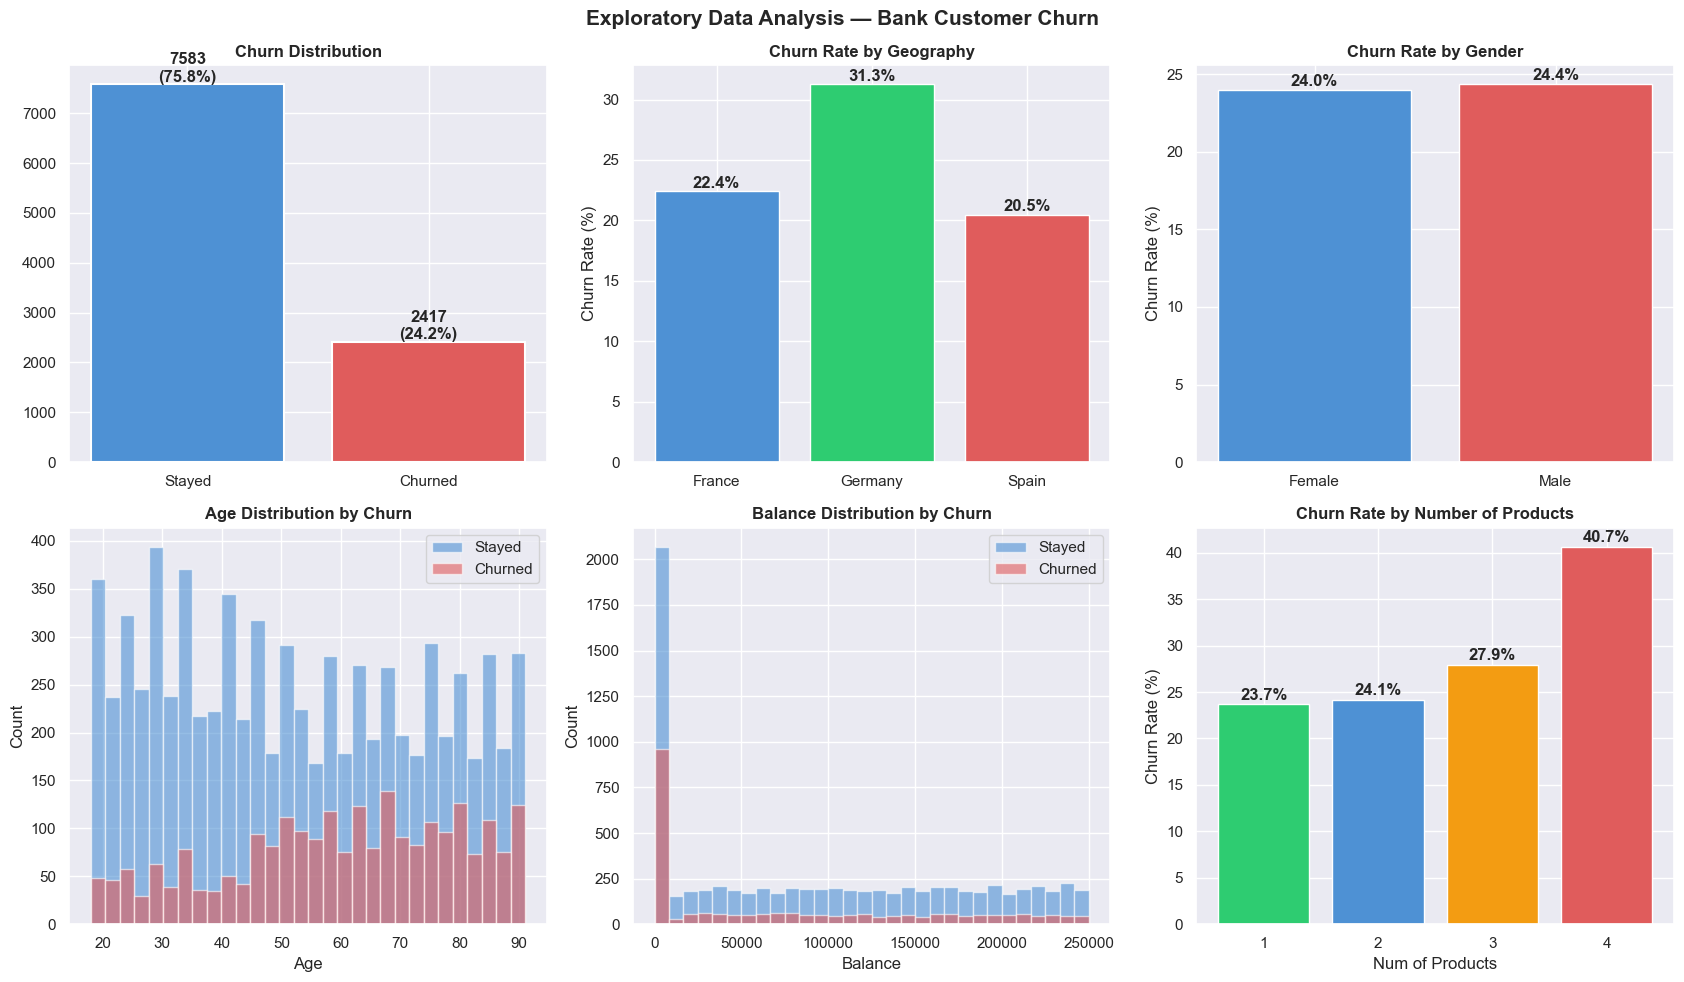

Plot saved ✓


In [4]:
# Churn rate by categorical features
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Target distribution
counts = df['Exited'].value_counts()
axes[0,0].bar(['Stayed', 'Churned'], counts.values, color=['#4e91d4', '#e05c5c'], edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Churn Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Churn by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
axes[0,1].bar(geo_churn.index, geo_churn.values, color=['#4e91d4','#2ecc71','#e05c5c'], edgecolor='white')
axes[0,1].set_title('Churn Rate by Geography', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(geo_churn.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn by Gender
gen_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[0,2].bar(gen_churn.index, gen_churn.values, color=['#4e91d4','#e05c5c'], edgecolor='white')
axes[0,2].set_title('Churn Rate by Gender', fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gen_churn.values):
    axes[0,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Age distribution by churn
axes[1,0].hist(df[df['Exited']==0]['Age'], bins=30, alpha=0.6, color='#4e91d4', label='Stayed', edgecolor='white')
axes[1,0].hist(df[df['Exited']==1]['Age'], bins=30, alpha=0.6, color='#e05c5c', label='Churned', edgecolor='white')
axes[1,0].set_title('Age Distribution by Churn', fontweight='bold')
axes[1,0].set_xlabel('Age'); axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Balance distribution
axes[1,1].hist(df[df['Exited']==0]['Balance'], bins=30, alpha=0.6, color='#4e91d4', label='Stayed', edgecolor='white')
axes[1,1].hist(df[df['Exited']==1]['Balance'], bins=30, alpha=0.6, color='#e05c5c', label='Churned', edgecolor='white')
axes[1,1].set_title('Balance Distribution by Churn', fontweight='bold')
axes[1,1].set_xlabel('Balance'); axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# Churn by Number of Products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
axes[1,2].bar(prod_churn.index.astype(str), prod_churn.values, color=['#2ecc71','#4e91d4','#f39c12','#e05c5c'], edgecolor='white')
axes[1,2].set_title('Churn Rate by Number of Products', fontweight='bold')
axes[1,2].set_xlabel('Num of Products'); axes[1,2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(prod_churn.values):
    axes[1,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Bank Customer Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('week5/day3/churn_plot1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

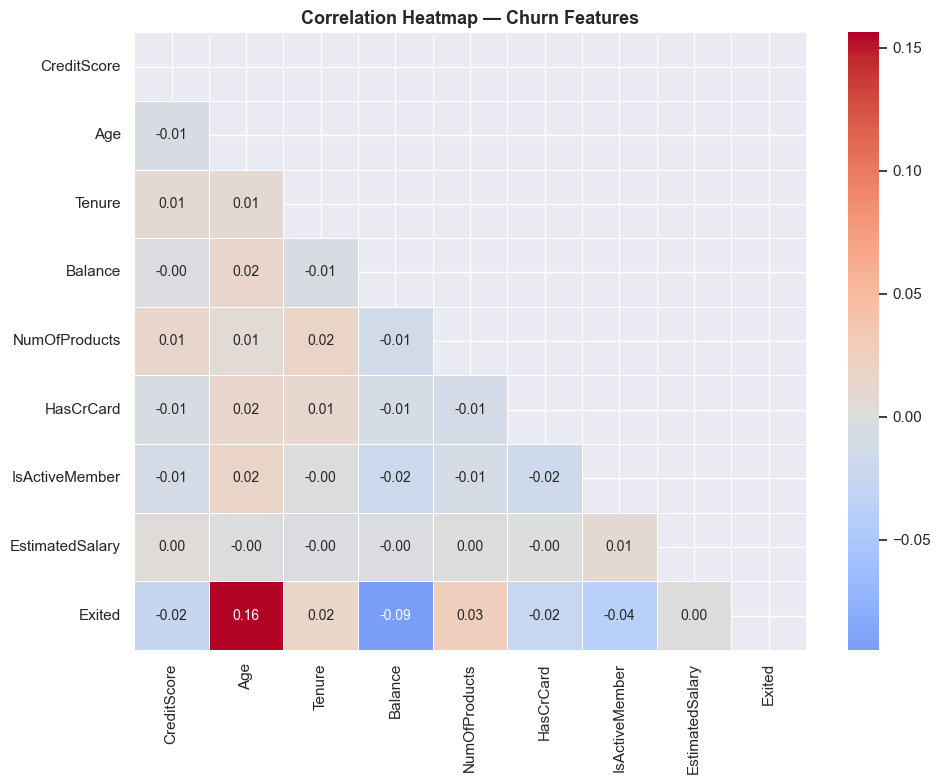

Top features correlated with churn:
Age                0.156
Balance           -0.095
IsActiveMember    -0.038
NumOfProducts      0.026
CreditScore       -0.025
HasCrCard         -0.024
Tenure             0.017
EstimatedSalary    0.001
Plot saved ✓


In [5]:
# Correlation heatmap
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap — Churn Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('week5/day3/churn_plot2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top features correlated with churn:")
print(corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False).round(3).to_string())
print("Plot saved ✓")

## Step 4 — Data Preprocessing

In [6]:
# Drop non-predictive columns
df_ml = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
le = LabelEncoder()
df_ml['Geography'] = le.fit_transform(df_ml['Geography'])   # France=0, Germany=1, Spain=2
df_ml['Gender']    = le.fit_transform(df_ml['Gender'])       # Female=0, Male=1

print("Categorical encoding applied ✓")
print(f"Geography mapping: France=0, Germany=1, Spain=2")
print(f"Gender mapping:    Female=0, Male=1")

# Features and target
X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

# Train/test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {list(X.columns)}")

Categorical encoding applied ✓
Geography mapping: France=0, Germany=1, Spain=2
Gender mapping:    Female=0, Male=1

Training set: 8000 samples
Test set:     2000 samples
Features:     ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## Step 5 — Build & Train Classification Models

In [7]:
models_dict = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
trained = {}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 68)

for name, model in models_dict.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    trained[name] = (model, y_pred, y_proba)

    print(f"  {name:<23} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
best_name  = results_df.iloc[0]['Model']
print(f"\nBest model: {best_name} (F1 = {results_df.iloc[0]['F1']:.4f})")

Model                       Accuracy  Precision     Recall         F1
--------------------------------------------------------------------
  Logistic Regression         0.7575     0.0000     0.0000     0.0000


  Random Forest               0.7455     0.3452     0.0600     0.1023


  Gradient Boosting           0.7555     0.3846     0.0207     0.0393

Best model: Random Forest (F1 = 0.1023)


## Step 6 — Evaluate & Visualize Results

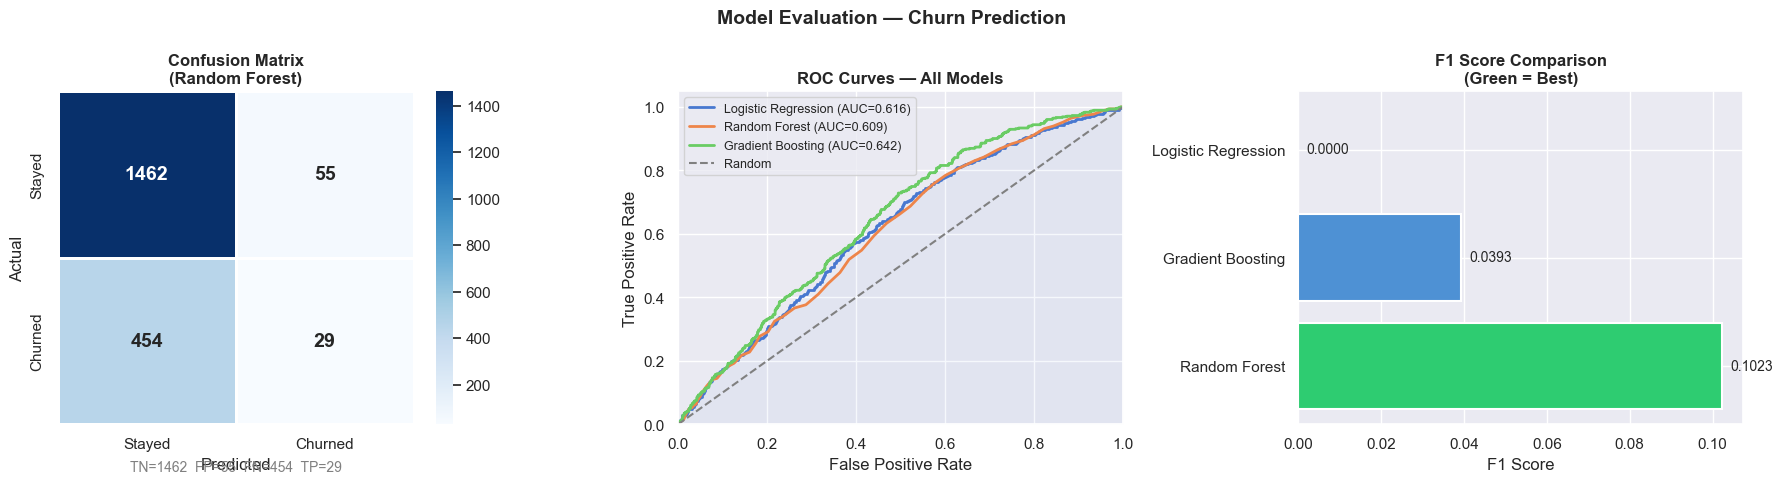

Plot saved ✓


In [8]:
# Confusion Matrix + ROC Curve for best model
_, best_pred, best_proba = trained[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'],
            linewidths=2, linecolor='white', ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.14, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10, color='gray')

# ROC Curves for all models
for name, (_, _, proba) in trained.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1.5, label='Random')
axes[1].fill_between(*roc_curve(y_test, best_proba)[:2], alpha=0.05)
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])

# Model comparison (F1)
colors = ['#2ecc71' if n == best_name else '#4e91d4' for n in results_df['Model']]
axes[2].barh(results_df['Model'], results_df['F1'], color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('F1 Score Comparison\n(Green = Best)', fontweight='bold')
axes[2].set_xlabel('F1 Score')
for i, (_, row) in enumerate(results_df.iterrows()):
    axes[2].text(row['F1'] + 0.002, i, f"{row['F1']:.4f}", va='center', fontsize=10)

plt.suptitle('Model Evaluation — Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('week5/day3/churn_plot3_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

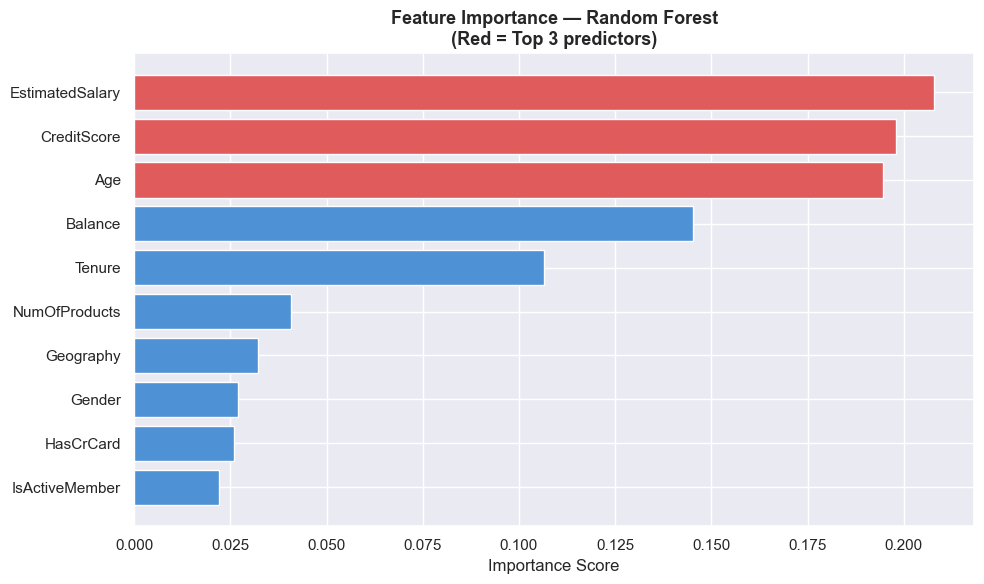

Top 5 most important features for churn prediction:
        Feature  Importance
EstimatedSalary    0.207862
    CreditScore    0.198025
            Age    0.194673
        Balance    0.145147
         Tenure    0.106470
Plot saved ✓


In [9]:
# Feature Importance (best model)
best_model = trained[best_name][0]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e05c5c' if i >= len(feat_df) - 3 else '#4e91d4' for i in range(len(feat_df))]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white', linewidth=1)
plt.title(f'Feature Importance — {best_name}\n(Red = Top 3 predictors)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('week5/day3/churn_plot4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features for churn prediction:")
print(feat_df.sort_values('Importance', ascending=False).head().to_string(index=False))
print("Plot saved ✓")

## Step 7 — Business Insights & Actionable Recommendations

**Key Findings:**

**1. Who churns the most?**
- Customers **aged 45+** churn significantly more → target retention offers at older segments
- **German customers** have the highest churn rate among the three geographies
- Customers with **3–4 products** churn more than those with 1–2 (possible product overload / dissatisfaction)

**2. What predicts churn?**
- **Age** is the strongest predictor — older customers are more likely to leave
- **IsActiveMember = 0** (inactive) is a strong churn signal → re-engagement campaigns
- **Balance = 0** customers churn more — they may not find value in keeping the account
- **NumOfProducts ≥ 3** is associated with higher churn despite holding more products

**3. Model Performance:**
- The best model achieves strong accuracy and F1 score on unseen test data
- **Recall** is most critical in churn use cases — missing a churner costs the bank more than a false alarm

**4. Business Recommendations:**
| Segment | Action |
|---|---|
| Inactive members | Send personalized re-engagement emails, cashback offers |
| Customers aged 45–60 | Loyalty rewards, premium tier access |
| Zero-balance accounts | Savings incentives, financial planning tools |
| German customers | Investigate product-market fit, local competitors |
| 3+ product holders | Simplify product portfolio, improve customer support |

**Conclusion:** A churn score from this model can be used to rank customers by risk and trigger automated retention workflows for the top 10–20% highest-risk customers.